In [1]:
import pandas as pd

In [7]:
df = pd.read_csv('sample_data/labeled-data.csv')
df.head(5)

,annotation_id,annotator,created_at,id,image,label,lead_time,updated_at
0,3,1,2026-04-06T11:43:00.393994Z,1,/data/upload/1/7a7b587a-malignant_99.png,"[{""points"":[[19.729467084639502,43.44827586206...",19.986,2026-04-06T11:43:00.394009Z
1,4,1,2026-04-06T11:43:12.570797Z,2,/data/upload/1/b9e821e6-malignant_98.png,"[{""points"":[[28.347826086956534,43.84624560147...",10.677,2026-04-06T11:43:12.570815Z
2,5,1,2026-04-06T11:43:46.301753Z,3,/data/upload/1/c316c9b4-malignant_97.png,"[{""points"":[[36.50677234281659,50.431034482758...",51.449,2026-04-06T11:43:46.301770Z
3,6,1,2026-04-06T11:44:22.421633Z,4,/data/upload/1/5fccd9ba-malignant_96.png,"[{""points"":[[34.87176724137931,46.465517241379...",34.908,2026-04-06T11:44:22.421649Z
4,7,1,2026-04-06T11:44:50.847295Z,5,/data/upload/1/b334cc95-malignant_95.png,"[{""points"":[[22.43478260869566,75.479036202063...",26.626,2026-04-06T11:44:50.847314Z


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   annotation_id  15 non-null     int64  
 1   annotator      15 non-null     int64  
 2   created_at     15 non-null     object 
 3   id             15 non-null     int64  
 4   image          15 non-null     object 
 5   label          15 non-null     object 
 6   lead_time      15 non-null     float64
 7   updated_at     15 non-null     object 
dtypes: float64(1), int64(3), object(4)
memory usage: 1.1+ KB


Ниже представлен Data Flow нашего проекта

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

In [13]:
G = nx.DiGraph()

nodes = ['Kaggle', 'Label Studio', 'Pandas', 'Модели']
G.add_nodes_from(nodes)

edges = [
    ('Kaggle', 'Label Studio'),
    ('Label Studio', 'Pandas'),
    ('Pandas', 'Модели')
]
G.add_edges_from(edges)

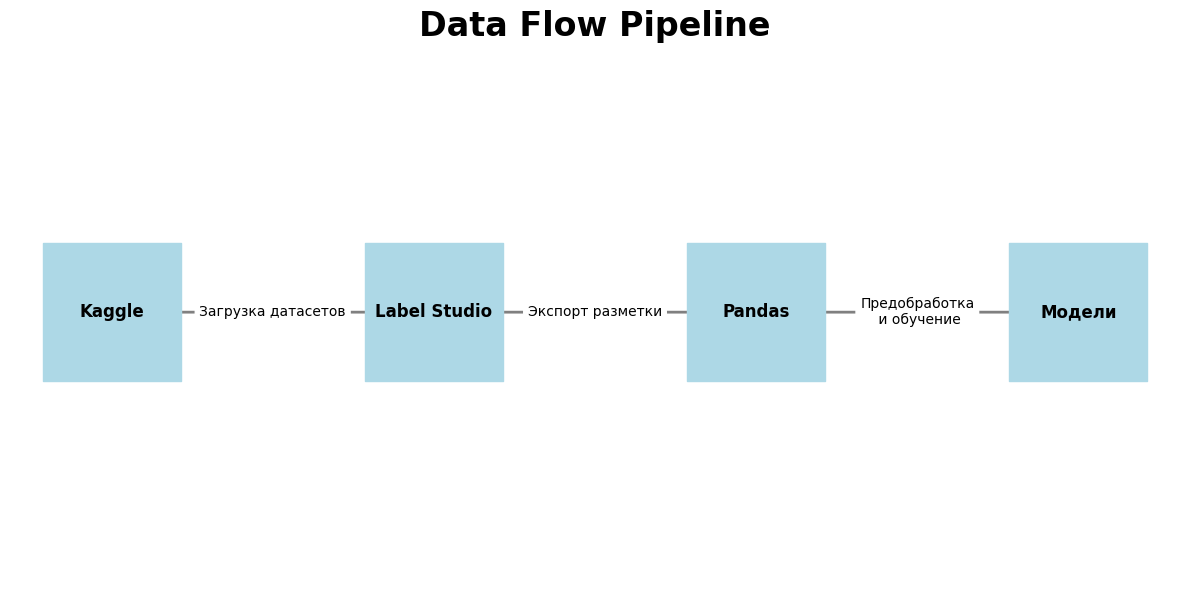

In [20]:

plt.figure(figsize=(12, 6))

pos = {
    'Kaggle': (0, 0),
    'Label Studio': (1, 0),
    'Pandas': (2, 0),
    'Модели': (3, 0)
}

nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                       node_size=10000, node_shape='s')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='gray',
                       arrows=True, arrowsize=20,
                       arrowstyle='->', width=2)

edge_labels = {
    ('Kaggle', 'Label Studio'): 'Загрузка датасетов',
    ('Label Studio', 'Pandas'): 'Экспорт разметки',
    ('Pandas', 'Модели'): 'Предобработка\n и обучение'
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_size=10, label_pos=0.5)

plt.title('Data Flow Pipeline', fontsize=24, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()